<a href="https://colab.research.google.com/github/ClaudioRo81/Diplomado-Tecnicas-Estadisticas-y-Mineria-de-Datos-Notebooks-Modulo-2/blob/main/Trabajo_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del crecimiento anual de la matrícula de posgrado mediante una distribución Normal
## Equipo 2
- *Alvarez Zavala Uriel Luis*
- *Bautista Coyotecatl Gerardo*
- *Rojas Duran Claudio*
- *Vega Barrera Efrén*

## Pregunta de investigación: ¿La matrícula de posgrado sigue una distribución normal? ¿Existe diferencia significativa en la matrícula promedio entre hombres y mujeres?

### 1. Identificación de la variable aleatoria

Se obtuvieron varias bases de datos de los años $2016$ al $2025$ de los posgrados del **Instituto Politécnico Nacional (IPN)** la cual se concentró en una sola base de datos para poder trabajar en ella.

La investigación plantea que si la matrícula de posgrado sigue una distribución normal y si existe diferencia significativa en la matrícula promedio entre hombres y mujeres.

Se identifica la variable la cual es:

$$X = \text{Crecimiento anual porcentual de la matrícula de posgrado}$$

**Justificación**

- Es una variable cuantitativa continua.
- Puede tomar valores positivos (crecimiento) y negativos (disminución).
- Los valores se concentran alrededor de una media (0.62%).
- Se desea modelar el comportamiento promedio y la variabilidad del crecimiento anual porcentual.
- Se desea ver la diferencia significativa en la matrícula promedio entre hombres y mujeres.

**Crecimiento Anual porcentual**

Para la fórmula principal es la del crecimiento porcentual anual la cual es:

$$C_t = \frac{M_t-M_{t-1}}{M_{t-1}}$$

donde:

- $C_t$= crecimiento porcentual en el año t
- $M_t$= matrícula del año actual
- $M_{t-1}$= matrícula del año anterior

**NOTA**: el primer valor ($2016$) se omite de la tabla por no tener crecimiento porcentual al ser el primer valor


| Id | Año | Matricula | Crecimiento |
| :--- | :--- | :--- | :--- |
| 1 | 2017 | 7050 | 0.009161 |
| 2 | 2018 | 6846 | -0.028936 |
| 3 | 2019 | 6564 | -0.041192 |
| 4 | 2020 | 6354 | -0.031993 |
| 5 | 2021 | 6753 | 0.062795 |
| 6 | 2022 | 6282 | -0.069747 |
| 7 | 2023 | 6409 | 0.020216 |
| 8 | 2024 | 6633 | 0.034951 |
| 9 | 2025 | 6644 | 0.001658 |


### Justificación de la distribución

Como primer paso cargaremos nuestra base de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

archivo = "Posgrados.xlsx"

# Leer todas las hojas
hojas = pd.read_excel(
    archivo,
    sheet_name=None
)
base_posgrados = pd.concat(
    hojas.values(),
    ignore_index=True
)
# Se tiene la variable todos los registros de todos los años
base_posgrados

,Año,nivel,dependencia,programa,nivel_asociado,hombre,mujer,descripcion_dependencia
0,2025,Posgrado,Centro Interdisciplinario de Ciencias Marinas,Doctorado en Bioeconomía Pesquera y Acuícola,Doctorado,2,2,NaN
1,2025,Posgrado,Centro de Investigación en Biotecnología Aplic...,Doctorado en Biotecnología Productiva,Doctorado,9,4,NaN
2,2025,Posgrado,Centro Interdisciplinario de Investigación par...,Doctorado en Ciencia y Tecnología de Ingenierí...,Doctorado,2,0,NaN
3,2025,Posgrado,"Escuela Superior de Ingeniería y Arquitectura,...",Doctorado en Ciencia y Tecnología de Ingenierí...,Doctorado,2,2,NaN
4,2025,Posgrado,Centro de Innovación y Desarrollo Tecnológico ...,Doctorado en Ciencia y Tecnología de Inteligen...,Doctorado,3,0,NaN
...,...,...,...,...,...,...,...,...
1740,2016,Nivel Posgrado,CICATA Legaria,Maestría en Tecnología Avanzada,Maestría,23,13,Centro de Investigación en Ciencia Aplicada y ...
1741,2016,Nivel Posgrado,CICATA Querétaro,Maestría en Tecnología Avanzada,Maestría,35,16,Centro de Investigación en Ciencia Aplicada y ...
1742,2016,Nivel Posgrado,CIITEC,Maestría en Tecnología Avanzada,Maestría,31,11,Centro de Investigación e Innovación Tecnológica
1743,2016,Nivel Posgrado,UPIITA,Maestría en Tecnología Avanzada,Maestría,21,11,Unidad Profesional Interdisciplinaria en Ingen...


Organizamos nuestros datos para que tengan su formato por año, maticula y crecimiento porcentual

In [2]:
# Se crea una columna con la matrícula total sumando hombres y mujeres
base_posgrados['Matricula_Total'] = base_posgrados['hombre'] + base_posgrados['mujer']

# Se crea una tabla resumen en donde se agrupan por años la cantidad de registros
registros_anuales = (
    base_posgrados
    .groupby("Año")["Matricula_Total"]
    .sum()
    .reset_index(name="Matricula")
)

# Se agrega la columna de crecimiento porcentual por año para su utilización
registros_anuales["Crecimiento"] = (
    registros_anuales["Matricula"]
    .pct_change()
)

# Se elimina el primer registro por no tener el crecimiento y se muestra la tabla final
crecimientos = registros_anuales.dropna()
crecimientos


,Año,Matricula,Crecimiento
1,2017,7050,0.009161
2,2018,6846,-0.028936
3,2019,6564,-0.041192
4,2020,6354,-0.031993
5,2021,6753,0.062795
6,2022,6282,-0.069747
7,2023,6409,0.020216
8,2024,6633,0.034951
9,2025,6644,0.001658


**Pruebas de Bondad de Ajuste**

Para verificar si nuestros datos se distribuyen como una normal, realizaremos dos pruebas de bondad de ajuste:
* **Prueba de Shapiro-Wilk**
* **Prueba de Anderson-Darling**

Adicionalmente, nos apoyaremos en el análisis visual mediante la gráfica de distribución de nuestros datos (histograma y curva de densidad) y un gráfico Q-Q (Cuantil-Cuantil) de normalidad.

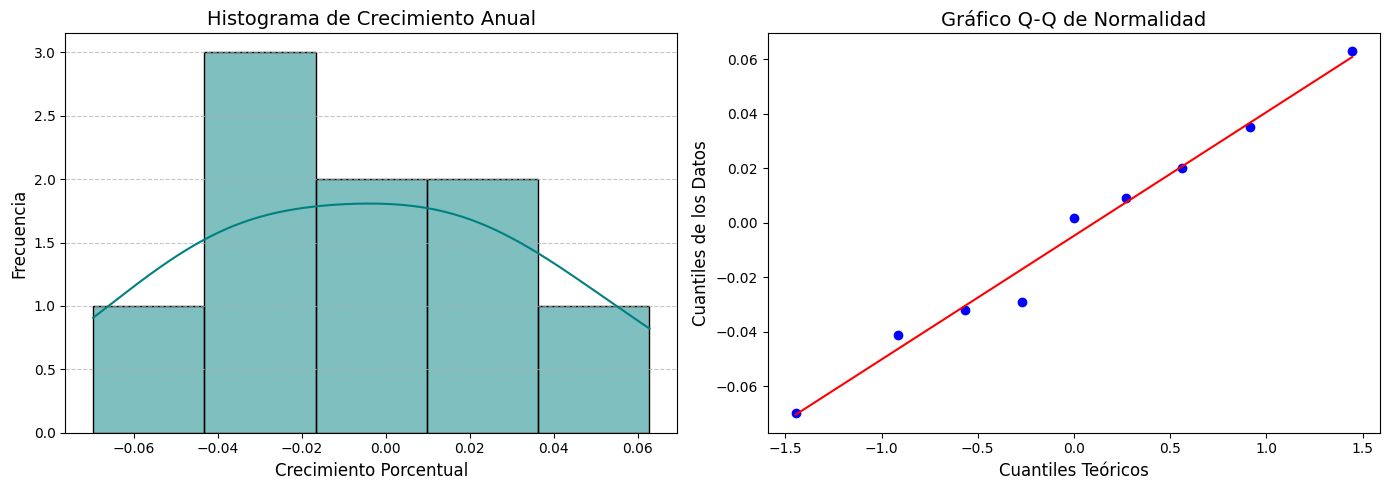

--------------------------------------------------
 RESULTADOS DE LAS PRUEBAS DE NORMALIDAD 
--------------------------------------------------
Hipótesis Nula (H0): Los datos siguen una distribución normal.

1. Prueba de Shapiro-Wilk (Ideal para n < 50):
   Estadístico = 0.9812
   p-valor = 0.9701
   Conclusión: NO se rechaza H0. Los datos muestran un comportamiento normal.


2. Prueba de Anderson-Darling:
   Estadístico = 0.1610
   Valor crítico (al 5%) = 0.6930
   Conclusión: NO se rechaza H0. Los datos muestran un comportamiento normal.


In [3]:
# Pruebas de Bondad de Ajuste para Normalidad
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Definimos nuestra variable de interés
X = crecimientos["Crecimiento"]

# Analizaremos visualmente
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histograma y Curva de Densidad
sns.histplot(X, kde=True, ax=ax[0], color='teal', bins=5)
ax[0].set_title('Histograma de Crecimiento Anual', fontsize=14)
ax[0].set_xlabel('Crecimiento Porcentual', fontsize=12)
ax[0].set_ylabel('Frecuencia', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico Q-Q (Cuantil-Cuantil)
# Si los puntos se pegan a la línea roja, los datos son normales.

stats.probplot(X, dist="norm", plot=ax[1])
ax[1].set_title('Gráfico Q-Q de Normalidad', fontsize=14)
ax[1].set_xlabel('Cuantiles Teóricos', fontsize=12)
ax[1].set_ylabel('Cuantiles de los Datos', fontsize=12)

plt.tight_layout()
plt.show()


# Pruebas estadisticas

alfa = 0.05 # Nivel de significancia del 5%

print("-" * 50)
print(" RESULTADOS DE LAS PRUEBAS DE NORMALIDAD ")
print("-" * 50)
print("Hipótesis Nula (H0): Los datos siguen una distribución normal.\n")

# Prueba de Shapiro-Wilk
stat_sw, p_sw = stats.shapiro(X)
print("1. Prueba de Shapiro-Wilk (Ideal para n < 50):")
print(f"   Estadístico = {stat_sw:.4f}")
print(f"   p-valor = {p_sw:.4f}")

if p_sw > alfa:
    print("   Conclusión: NO se rechaza H0. Los datos muestran un comportamiento normal.")
else:
    print("   Conclusión: Se rechaza H0. Los datos NO muestran un comportamiento normal.")

print("\n")

# Prueba de Anderson-Darling
resultado_ad = stats.anderson(X, dist='norm')
# El índice 2 corresponde al nivel de significancia del 5% (alfa = 0.05)
valor_critico_5 = resultado_ad.critical_values[2]

print("2. Prueba de Anderson-Darling:")
print(f"   Estadístico = {resultado_ad.statistic:.4f}")
print(f"   Valor crítico (al 5%) = {valor_critico_5:.4f}")

if resultado_ad.statistic < valor_critico_5:
    print("   Conclusión: NO se rechaza H0. Los datos muestran un comportamiento normal.")
else:
    print("   Conclusión: Se rechaza H0. Los datos NO muestran un comportamiento normal.")


**Conclusión de Normalidad**

Con base en los resultados estadísticos, se concluye que el crecimiento anual porcentual de **la matrícula sigue una distribución normal** debido a que no existe evidencia suficiente para rechazar la hipótesis nula (H0).

**Por Shapiro-Wilk:** El valor p obtenido (0.9701) podemos ver que es mayor al nivel de significancia estándar de 0.05.

**Por Anderson-Darling:** El estadístico de prueba calculado (0.1610) es inferior al valor crítico límite (0.6930) al 5%.

Al cumplirse ambas condiciones empíricas, se confirma que la variable se ajusta a una distribución normal.

### 2. Estimación puntual

#### Estimadores de Máxima Verosimilitud (MLE)

Para encontrar los estimadores puntuales de la distribución Normal para nuestra variable de crecimiento anual, partimos de la función de densidad de probabilidad:

$$f(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

### Paso 1: Función de Verosimilitud
Asumiendo que nuestras observaciones $x_1, x_2, ..., x_n$ son independientes e idénticamente distribuidas, la función de verosimilitud $L$ es el producto de las densidades marginales:

$$L(\mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

### Paso 2: Log-Verosimilitud
Para facilitar la derivación, aplicamos el logaritmo natural, obteniendo la función de log-verosimilitud $l(\mu, \sigma^2)$:

$$l(\mu, \sigma^2) = \ln L(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

### Paso 3: Estimador de la Media ($\hat{\mu}$)
Derivamos la función de log-verosimilitud con respecto a $\mu$ y la igualamos a cero para encontrar el máximo:

$$\frac{\partial l}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0$$

Como la varianza no puede ser cero, multiplicamos por $\sigma^2$ y resolvemos para $\mu$:

$$\sum_{i=1}^{n}x_i - n\mu = 0$$
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n}x_i$$

### Paso 4: Estimador de la Varianza ($\hat{\sigma}^2$)
Derivamos la función con respecto a $\sigma^2$ (tratándola como una sola variable) y la igualamos a cero:

$$\frac{\partial l}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i - \mu)^2 = 0$$

Multiplicamos toda la expresión por $2(\sigma^2)^2$ y sustituimos $\mu$ por su estimador $\hat{\mu}$:

$$-n\sigma^2 + \sum_{i=1}^{n}(x_i - \hat{\mu})^2 = 0$$
$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{\mu})^2$$

De este desarrollo analítico obtenemos exactamente las fórmulas que se aplicarán en código para estimar los parámetros poblacionales de la matrícula.

In [4]:
# Extraemos la variable X
X = crecimientos["Crecimiento"]

# Estimación Puntual de la Media (MLE)
mu_mle = np.mean(X)

# Estimación Puntual de la Varianza (MLE)
# Usamos ddof=0 para dividir entre 'n' en lugar de 'n-1'
var_mle = np.var(X, ddof=0)

# Estimación Puntual de la Desviación Estándar (MLE)
sigma_mle = np.std(X, ddof=0)

print("Estimadores por Máxima Verosimilitud (MLE)")
print(f"Media (μ̂): {mu_mle:.4f}")
print(f"Varianza (σ̂²): {var_mle:.6f}")

Estimadores por Máxima Verosimilitud (MLE)
Media (μ̂): -0.0048
Varianza (σ̂²): 0.001542


Por lo tanto los Estimadores por Máxima Verosimilitud (MLE) son:

$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^nx_i = -0.0048$$

$$\hat{\sigma^2} = \frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu})^2= 0.001542$$

en donde:

- $\mu$ es la media
- $\sigma^2$ es la varianza
- $x_i$ es el crecimiento anual porcentual del año $i$
- $n$ es el número total de años


###Visualización de la Distribución Teórica

Con base en los resultados anteriores que confirman la normalidad de los datos, el siguiente bloque de código modela visualmente la distribución teórica de nuestra variable.

Para lograrlo, se calculan los estimadores muestrales de la media y la desviación estándar. Posteriormente, se genera la Función de Densidad de Probabilidad utilizando estos parámetros

Media: -0.0048
Desviacion estandar 0.0416


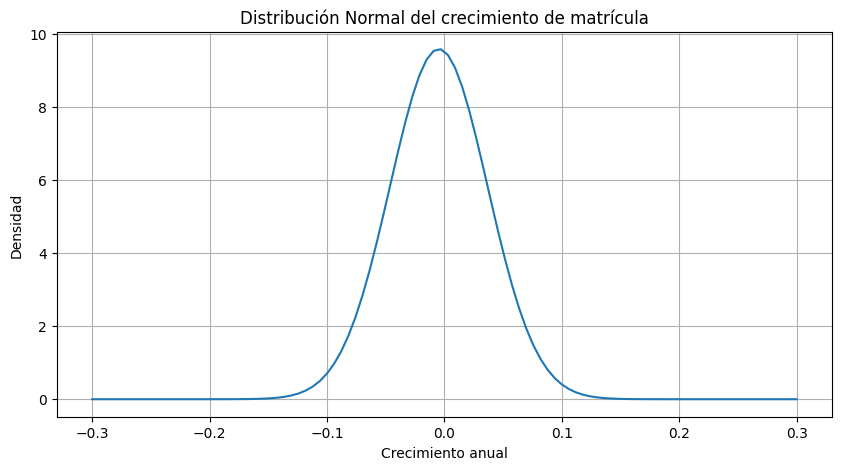

In [9]:
# parámetros de media y desviacion estandar
media = crecimientos["Crecimiento"].mean()
desv = crecimientos["Crecimiento"].std()

print(f"Media: {media:.4f}")
print(f"Desviacion estandar {desv:.4f}")


# valores de X
x = np.linspace(
    -0.3,
    0.3,
    100
)

# densidad normal y se hace la grafica de la normal
y = norm.pdf(x,media,desv)

plt.figure(figsize=(10,5))

plt.plot(x,y)

plt.xlabel("Crecimiento anual")
plt.ylabel("Densidad")
plt.title("Distribución Normal del crecimiento de matrícula")

plt.grid(True)

plt.show()

**Interpretación de la Gráfica:**

La curva resultante representa la distribución Normal teórica ajustada a nuestros datos históricos. Podemos observar lo siguiente:

*   **Tendencia Central:** La campana está centrada alrededor de la media estimada (aproximadamente **-0.0048**). Visualmente, el pico de máxima densidad se encuentra prácticamente sobre el eje del **0**.
*   **Dispersión (Varianza):** La amplitud de la campana, dictada por la desviación estándar, nos muestra cómo se distribuyen las probabilidades. La mayor parte del área bajo la curva se concentra entre **-0.10** y **0.10**.

### 3. Intervalo de confianza al 95%

**Prueba de Hipótesis para la Media e Intervalo de Confianza**

Para evaluar si existe un crecimiento significativo en la matrícula, planteamos las siguientes hipótesis:

*   **$H_0$:** La matrícula no presenta un crecimiento promedio significativo ($\mu = 0$).
*   **$H_1$:** La matrícula presenta un crecimiento promedio estadísticamente diferente de cero ($\mu \neq 0$).

Dado que la muestra es pequeña ($n=9$), se utiliza la distribución $t$ de Student para la estimación del intervalo de confianza:

$$IC = \hat{x} \pm t_{\alpha/2, n-1} \left( \frac{s}{\sqrt{n}} \right)$$

**Datos muestrales:**
*   $\hat{x}$ (Media muestral) = -0.0048
*   $s$ (Desviación estándar muestral insesgada) = 0.0416
*   $n$ (Número de observaciones) = 9
*   $gl$ (Grados de libertad, $n-1$) = 8
*   $t_{0.025, 8}$ (Valor crítico al 95% de confianza) = 2.306

**Cálculo del Intervalo de Confianza:**
El Margen de Error ($ME$) se calcula como:
$$ME = 2.306 \left( \frac{0.0416}{\sqrt{9}} \right) = 0.032$$

Aplicando el margen de error a nuestra media:
$$LI = \hat{x} - ME = -0.0048 - 0.032 = -0.0368$$
$$LS = \hat{x} + ME = -0.0048 + 0.032 = 0.0272$$

$$IC_{95\%} = (-3.68\%, 2.72\%)$$

**Estadístico de prueba $t$:**
Para corroborar el resultado, calculamos el estadístico de prueba:
$$t = \frac{\hat{x} - \mu_0}{s / \sqrt{n}}$$

Sustituyendo los valores con nuestra $\mu_0 = 0$:
$$t = \frac{-0.0048 - 0}{0.0416 / 3} = -0.346$$

**Conclusión:**
El valor absoluto de nuestro estadístico de prueba ($|t| = 0.346$) es menor que el valor crítico de tablas ($t_{critico} = 2.306$), por lo tanto, **no se rechaza $H_0$**.

Con un nivel de confianza del 95%, el crecimiento promedio anual de la matrícula de posgrado se encuentra entre una disminución del 3.68% y un crecimiento del 2.72%. Debido a que el intervalo incluye el valor 0%, no existe evidencia estadística suficiente para afirmar que la matrícula tenga un crecimiento o decremento promedio diferente de cero.

#### Cálculo computacional del Intervalo de Confianza

Para validar nuestro desarrollo analítico, el siguiente bloque de código implementa la estimación del intervalo de confianza al 95% utilizando la distribución $t$ de Student a través de la librería `scipy.stats`.

Este script extrae dinámicamente los parámetros de nuestra muestra (media y desviación estándar insesgada) y calcula el valor crítico, el margen de error y los límites inferior y superior, presentando los resultados en formato porcentual.

In [10]:
from scipy.stats import t

# se crea un array del crecimiento porcentual anual para la t
x = crecimientos["Crecimiento"]

n = len(x)
media = x.mean()
s = x.std(ddof=1)

# se agrega la confianza del 95%
confianza = 0.95
alpha = 1 - confianza
# con los datos se utiliza la funcion de la t
t_critico = t.ppf(1-alpha/2, df=n-1)

error = t_critico * s / np.sqrt(n)
# asimismo, se hace el error critico, el limite superior y el limite inferior
LI = media - error
LS = media + error

print("Resultados del Intervalo de Confianza (95%)")
print(f"Valor t Crítico: {t_critico:.3f}")
print(f"Margen de Error (ME): {error * 100:.3f}%")
print(f"Límite Inferior (LI): {LI * 100:.3f}%")
print(f"Límite Superior (LS): {LS * 100:.3f}%")

Resultados del Intervalo de Confianza (95%)
Valor t Crítico: 2.306
Margen de Error (ME): 3.201%
Límite Inferior (LI): -3.680%
Límite Superior (LS): 2.723%


**Comprobación Empírica de Resultados:**

Como se puede observar en la salida de ejecución, los valores calculados computacionalmente coinciden con nuestro desarrollo matemático previo.

El intervalo de confianza del **95%** va de **-3.680%** a **2.723%**.

####Visualización de la Región de Aceptación y Zonas Críticas

Para comprender gráficamente la decisión estadística tomada, modelaremos la distribución teórica de nuestro estadístico de prueba. Dado que nuestra muestra es pequeña ($n=9$), el estadístico se comporta bajo una distribución **t de Student** con 8 grados de libertad.

El siguiente bloque de código genera la forma de esta distribución. Posteriormente, se trazan los **valores críticos** (líneas verticales punteadas) que delimitan nuestro nivel de confianza del 95%. Cualquier valor que caiga entre estas dos líneas indica que el resultado es estadísticamente compatible con la Hipótesis Nula ($H_0$).

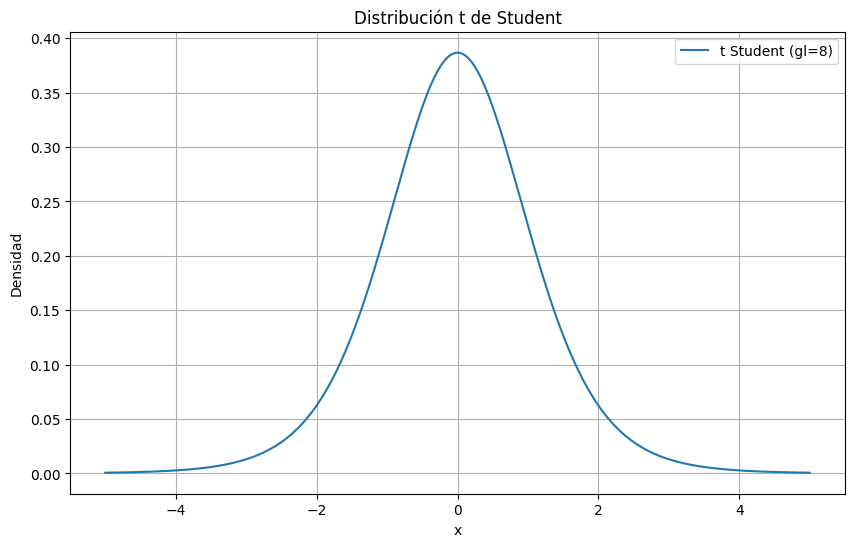

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# rango de valores
x = np.linspace(-5, 5, 300)

# grados de libertad el cual se saca de n=9-1
gl = 8

# función de densidad t Student
y = t.pdf(x, gl)

plt.figure(figsize=(10,6))

plt.plot(x, y, label=f"t Student (gl={gl})")

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Distribución t de Student")
plt.legend()
plt.grid(True)

plt.show()

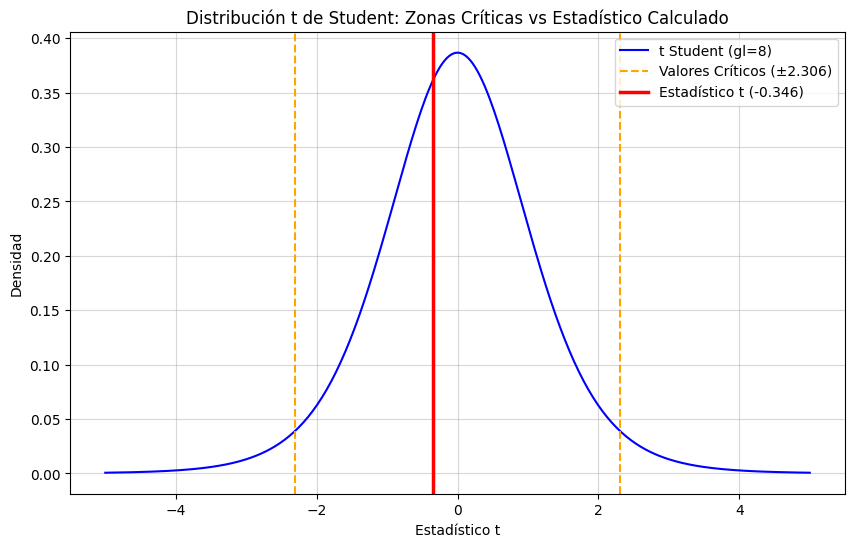

In [13]:
t_critico = t.ppf(0.975, gl)

# Nuestro estadístico de prueba calculado
t_calculado = -0.346

plt.figure(figsize=(10,6))

# Se crea la gráfica de la distribución teórica
plt.plot(x, y, label=f"t Student (gl={gl})", color="blue")

# Se trazan las líneas de los valores críticos (Límites del IC 95%)
plt.axvline(-t_critico, color="orange", linestyle="--", label=f"Valores Críticos (±{t_critico:.3f})")
plt.axvline(t_critico, color="orange", linestyle="--")

# Se traza la línea de nuestro estadístico de prueba
plt.axvline(t_calculado, color="red", linestyle="-", linewidth=2.5, label=f"Estadístico t ({t_calculado:.3f})")

plt.xlabel("Estadístico t")
plt.ylabel("Densidad")
plt.title("Distribución t de Student: Zonas Críticas vs Estadístico Calculado")

plt.grid(True, alpha=0.5)
plt.legend()

plt.show()

**Interpretación de las Zonas Críticas:**

En la segunda gráfica, las líneas verticales punteadas representan nuestros fronteras o **valores críticos** ($t \approx \pm 2.306$).

*   **Zona de no rechazo:** El área central contenida entre estas dos líneas engloba el **95% de la probabilidad**.
*   **Zonas de rechazo (Colas):** Las áreas en los extremos hacia afuera de las líneas punteadas representan el 5% de probabilidad de error (2.5% en cada cola).

Nuestro estadístico de prueba calculado previamente fue de **$t = -0.346$**. Si ubicamos ese valor en el eje $x$ de la gráfica, podemos notar que se encuentra muy cerca del centro (cero), cayendo dentro del área delimitada por las líneas. Esta es la demostración gráfica de por qué no existe evidencia suficiente para rechazar $H_0$; el crecimiento observado es producto de la variabilidad natural y no representa un cambio estadísticamente significativo.

### Conclusión

El análisis del crecimiento anual porcentual de la matrícula de posgrado entre 2017 y 2025 muestra que las variaciones pueden aproximarse mediante una distribución Normal con media cercana al -0.48% y una desviación estándar de 4.16%. Aunque existen años con incrementos importantes, como 2021 y 2024, y disminuciones relevantes, como 2019 y 2022, la prueba estadística indica que no existe evidencia suficiente para afirmar que el crecimiento promedio anual sea significativamente diferente de cero.

En consecuencia, los cambios observados pueden interpretarse como fluctuaciones naturales de la matrícula y no necesariamente como una tendencia sostenida de crecimiento.

### Base de datos

- Instituto Politécnico Nacional. (2016-2025). Matrícula por programa académico de nivel posgrado [Bases de datos anuales]. Gobierno de México. https://www.datos.gob.mx/dataset/matricula_programa_academico_nivel_posgrado